# Tonelli's Theorem in Measure Theory & Probability Theory

## Measure-Theoretic Statement

Let $(X, \mathcal{A}, \mu)$ and $(Y, \mathcal{B}, \nu)$ be **$\sigma$-finite** measure spaces, and let $(X \times Y, \mathcal{A} \otimes \mathcal{B}, \mu \otimes \nu)$ be their product measure space.

If $f: X \times Y \to [0, \infty]$ is a **non-negative measurable** function, then:

1. For every $x \in X$, the section $f_x(y) = f(x,y)$ is measurable on $Y$
2. For every $y \in Y$, the section $f^y(x) = f(x,y)$ is measurable on $X$
3. The functions $x \mapsto \int_Y f(x,y) \, d\nu(y)$ and $y \mapsto \int_X f(x,y) \, d\mu(x)$ are measurable
4. The iterated integrals are equal and equal the product integral:

$$\int_X \left( \int_Y f(x,y) \, d\nu(y) \right) d\mu(x) = \int_Y \left( \int_X f(x,y) \, d\mu(x) \right) d\nu(y) = \int_{X \times Y} f(x,y) \, d(\mu \otimes \nu)(x,y)$$

**Crucially**, this equality holds even when the common value is $+\infty$.

### Comparison with Fubini

| | Fubini | Tonelli |
|---|---|---|
| **Sign condition** | $f$ absolutely integrable: $\int \|f\| < \infty$ | $f \geq 0$ (non-negative) |
| **Conclusion** | Iterated integrals equal and are finite | Iterated integrals equal (possibly $+\infty$) |
| **Use case** | Signed functions, general expectations | Non-negative functions, checking integrability |

Tonelli is often used **before** Fubini: apply Tonelli to $|f|$ to verify $\int |f| < \infty$, then apply Fubini to $f$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D

np.random.seed(42)

## Tonelli's Theorem in Probability Theory

In probability, Tonelli's theorem is essential because many quantities of interest are **non-negative**:

### 1. Tail Probability Formula
For a non-negative random variable $X \geq 0$:

$$\mathbb{E}[X] = \int_0^\infty \mathbb{P}(X > t) \, dt = \int_0^\infty S_X(t) \, dt$$

**Proof via Tonelli**: Write $X = \int_0^\infty \mathbf{1}_{\{X > t\}} \, dt$. Then:

$$\mathbb{E}[X] = \mathbb{E}\left[\int_0^\infty \mathbf{1}_{\{X > t\}} \, dt\right] = \int_0^\infty \mathbb{E}[\mathbf{1}_{\{X > t\}}] \, dt = \int_0^\infty \mathbb{P}(X > t) \, dt$$

The interchange of expectation and integral is justified by Tonelli since the integrand is non-negative.

### 2. Non-Negative Functions of Random Variables
For any non-negative measurable $g \geq 0$:

$$\mathbb{E}[g(X,Y)] = \int_{\mathbb{R}^2} g(x,y) \, dF_{X,Y}(x,y)$$

Tonelli guarantees we can compute this as an iterated integral in either order, even if the expectation is infinite.

### 3. Checking Integrability
To apply Fubini to a signed function $f$, first apply Tonelli to $|f|$:
- If $\int |f| \, d(\mu \otimes \nu) < \infty$, then Fubini applies to $f$
- If $\int |f| \, d(\mu \otimes \nu) = \infty$, then Fubini may fail

In [2]:
# --- Example 1: Tail Probability Formula ---
# X ~ Exponential(lambda). E[X] = 1/lambda.
# Verify: E[X] = integral_0^inf P(X > t) dt

lam = 0.5
t_max = 100  # Approximate infinity
n_points = 20000

t = np.linspace(0, t_max, n_points)
survival = np.exp(-lam * t)  # P(X > t) = e^{-lambda t}

# E[X] via tail probability (Tonelli justifies this)
E_X_tail = np.trapezoid(survival, t)

# E[X] via direct integration
x = np.linspace(0, t_max, n_points)
pdf = lam * np.exp(-lam * x)
E_X_direct = np.trapezoid(x * pdf, x)

# Analytical
E_X_analytical = 1 / lam

print(f"lambda = {lam}")
print(f"E[X] via tail probability (Tonelli): {E_X_tail:.6f}")
print(f"E[X] via direct integration:         {E_X_direct:.6f}")
print(f"Analytical E[X] = 1/lambda:          {E_X_analytical:.6f}")
print(f"Difference: {abs(E_X_tail - E_X_analytical):.2e}")


lambda = 0.5
E[X] via tail probability (Tonelli): 2.000001
E[X] via direct integration:         1.999999
Analytical E[X] = 1/lambda:          2.000000
Difference: 1.04e-06


# Visualization 1: The Tail Probability Identity

The identity $\mathbb{E}[X] = \int_0^\infty \mathbb{P}(X > t) \, dt$ comes from integrating the **indicator** $\mathbf{1}_{\{t < X\}}$ over the product space $[0,\infty) \times \Omega$.

Equivalently, for a random variable with density $f_X$:
$$\mathbb{E}[X] = \int_0^\infty \int_t^\infty f_X(x) \, dx \, dt = \int_0^\infty \int_0^x f_X(x) \, dt \, dx$$

The plots below show:
- **Top-left**: The PDF $f_X(x)$
- **Top-right**: The survival function $S_X(t) = \mathbb{P}(X > t)$
- **Bottom-left**: Integration strips for $\int_t^\infty f_X(x)\,dx$ (horizontal slices)
- **Bottom-right**: Integration strips for $\int_0^x dt$ (vertical slices)

Both integrate to the same area $\mathbb{E}[X]$.


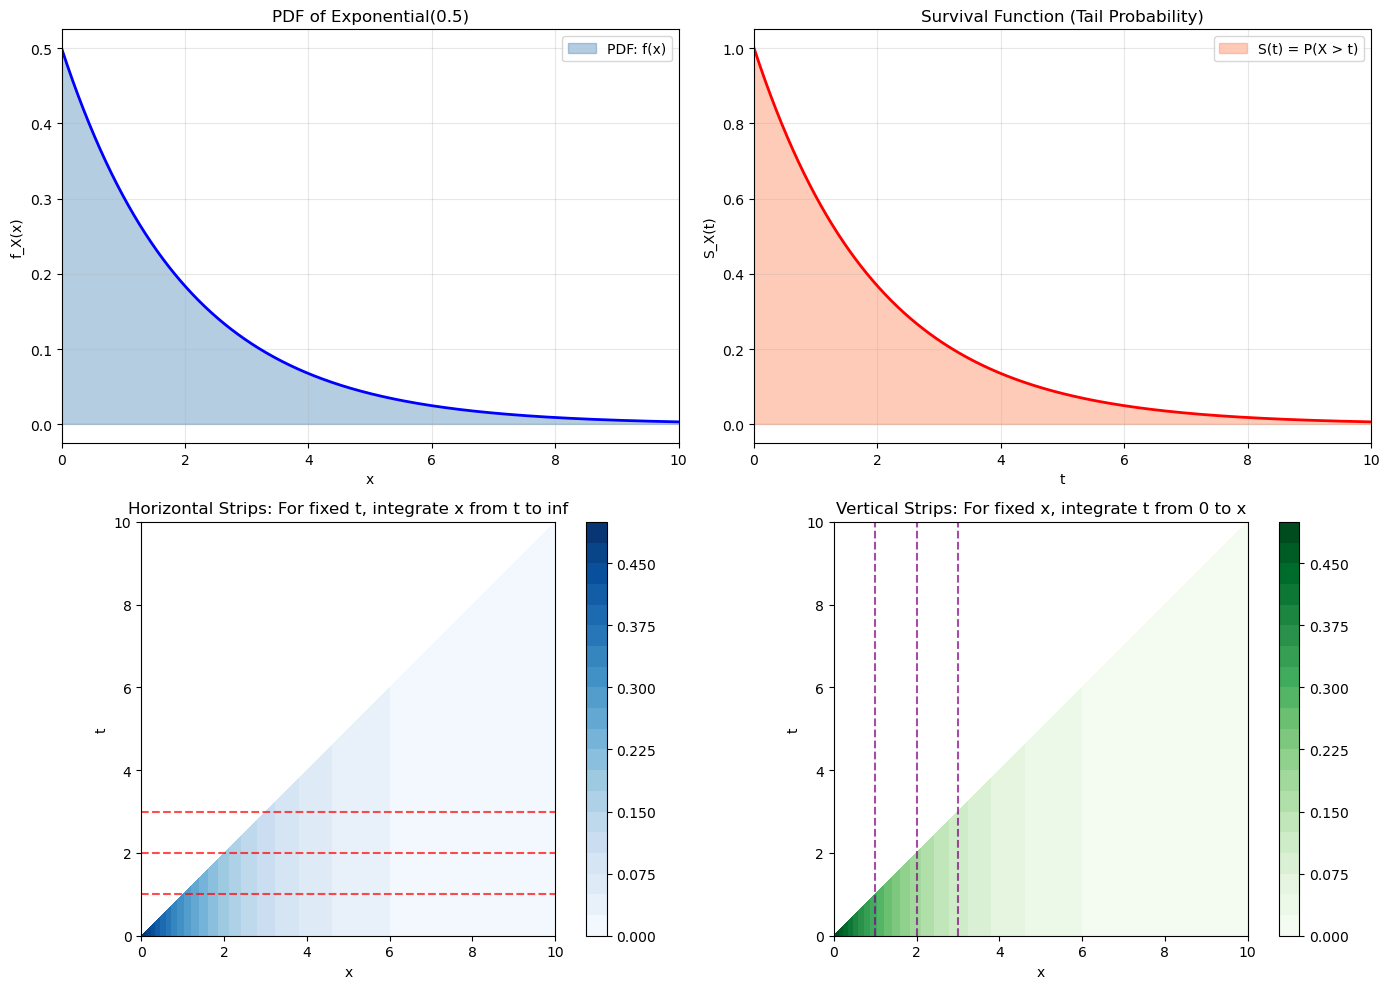

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: PDF
ax1 = axes[0, 0]
ax1.fill_between(x, pdf, alpha=0.4, color='steelblue', label='PDF: f(x)')
ax1.plot(x, pdf, 'b-', linewidth=2)
ax1.set_xlabel('x')
ax1.set_ylabel('f_X(x)')
ax1.set_title('PDF of Exponential({})'.format(lam))
ax1.set_xlim(0, 10)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Top-right: Survival function
ax2 = axes[0, 1]
ax2.fill_between(t, survival, alpha=0.4, color='coral', label='S(t) = P(X > t)')
ax2.plot(t, survival, 'r-', linewidth=2)
ax2.set_xlabel('t')
ax2.set_ylabel('S_X(t)')
ax2.set_title('Survival Function (Tail Probability)')
ax2.set_xlim(0, 10)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom-left: Horizontal strips (integrate over x for fixed t)
ax3 = axes[1, 0]
x_vis = np.linspace(0, 10, 500)
t_vis = np.linspace(0, 10, 500)
X_vis, T_vis = np.meshgrid(x_vis, t_vis)
Z_left = np.where(T_vis <= X_vis, lam * np.exp(-lam * X_vis), np.nan)
contour1 = ax3.contourf(X_vis, T_vis, Z_left, levels=20, cmap=cm.Blues)
ax3.set_xlabel('x')
ax3.set_ylabel('t')
ax3.set_title('Horizontal Strips: For fixed t, integrate x from t to inf')
ax3.set_aspect('equal')
fig.colorbar(contour1, ax=ax3)

for tv in [1, 2, 3]:
    ax3.axhline(tv, color='red', linestyle='--', alpha=0.7)

# Bottom-right: Vertical strips (integrate over t for fixed x)
ax4 = axes[1, 1]
Z_right = np.where(T_vis <= X_vis, lam * np.exp(-lam * X_vis), np.nan)
contour2 = ax4.contourf(X_vis, T_vis, Z_right, levels=20, cmap=cm.Greens)
ax4.set_xlabel('x')
ax4.set_ylabel('t')
ax4.set_title('Vertical Strips: For fixed x, integrate t from 0 to x')
ax4.set_aspect('equal')
fig.colorbar(contour2, ax=ax4)

for xv in [1, 2, 3]:
    ax4.axvline(xv, color='purple', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Example 2: Non-Negative Joint Expectations

Consider independent exponential random variables $X, Y \sim \text{Exp}(1)$. The joint density is:

$$f_{X,Y}(x,y) = e^{-(x+y)}, \quad x,y \geq 0$$

Since $g(x,y) = xy \geq 0$ and $h(x,y) = \max(x,y) \geq 0$, Tonelli's theorem applies directly.

### Analytical Results
- $\mathbb{E}[XY] = \mathbb{E}[X]\mathbb{E}[Y] = 1 \cdot 1 = 1$
- $\mathbb{E}[\max(X,Y)] = \frac{3}{2}$ (for i.i.d. Exp(1))

We verify numerically that iterated integration in either order yields the same result.

In [4]:
# --- Example 2: Joint Expectations for Non-Negative Functions ---
# X, Y ~ Exp(1), independent. Joint density: f(x,y) = e^{-(x+y)}

lim = 15  # Truncation for numerical integration
n = 400
x_j = np.linspace(0, lim, n)
y_j = np.linspace(0, lim, n)
X_j, Y_j = np.meshgrid(x_j, y_j)

joint_exp = np.exp(-(X_j + Y_j))

# g(x,y) = xy
g1 = X_j * Y_j * joint_exp
inner_y_g1 = np.array([np.trapezoid(g1[i, :], y_j) for i in range(len(x_j))])
E_xy_xy = np.trapezoid(inner_y_g1, x_j)

inner_x_g1 = np.array([np.trapezoid(g1[:, j], x_j) for j in range(len(y_j))])
E_xy_yx = np.trapezoid(inner_x_g1, y_j)

# h(x,y) = max(x,y)
g2 = np.maximum(X_j, Y_j) * joint_exp
inner_y_g2 = np.array([np.trapezoid(g2[i, :], y_j) for i in range(len(x_j))])
E_max_xy = np.trapezoid(inner_y_g2, x_j)

inner_x_g2 = np.array([np.trapezoid(g2[:, j], x_j) for j in range(len(y_j))])
E_max_yx = np.trapezoid(inner_x_g2, y_j)

print("Non-negative joint expectations (Tonelli applies):")
print(f"E[XY]       (dy dx): {E_xy_xy:.6f}")
print(f"E[XY]       (dx dy): {E_xy_yx:.6f}")
print(f"Analytical:           1.000000")
print()
print(f"E[max(X,Y)] (dy dx): {E_max_xy:.6f}")
print(f"E[max(X,Y)] (dx dy): {E_max_yx:.6f}")
print(f"Analytical:           1.500000")


Non-negative joint expectations (Tonelli applies):
E[XY]       (dy dx): 0.999755
E[XY]       (dx dy): 0.999755
Analytical:           1.000000

E[max(X,Y)] (dy dx): 1.500167
E[max(X,Y)] (dx dy): 1.500167
Analytical:           1.500000


## Example 3: Infinite Expectation (Tonelli Gives $+\infty$)

Tonelli's theorem remains valid even when the integral is infinite. This is crucial for detecting when Fubini **cannot** be applied.

Consider a **Pareto distribution** with shape parameter $\alpha = 1$ and scale $x_m = 1$:

$$f_X(x) = \frac{1}{x^2}, \quad x \geq 1$$

The tail probability is $\mathbb{P}(X > t) = \frac{1}{t}$ for $t \geq 1$.

### Analysis
- Direct: $\mathbb{E}[X] = \int_1^\infty x \cdot \frac{1}{x^2} \, dx = \int_1^\infty \frac{1}{x} \, dx = +\infty$
- Tail formula: $\mathbb{E}[X] = \int_1^\infty \frac{1}{t} \, dt = +\infty$

Both methods correctly yield infinity. Since $X \geq 0$, Tonelli guarantees the tail formula is valid. Because $\mathbb{E}[X] = \infty$, Fubini's theorem does **not** apply to the signed formulation.

We demonstrate numerically that as the upper limit increases, both integrals diverge logarithmically.

Pareto(1,1) - Divergence of E[X]:
 Upper Limit       Direct         Tail       log(L)
-------------------------------------------------------
          10       2.3026       2.3026       2.3026
         100       4.6052       4.6052       4.6052
        1000       6.9080       6.9080       6.9078
       10000       9.2307       9.2307       9.2103


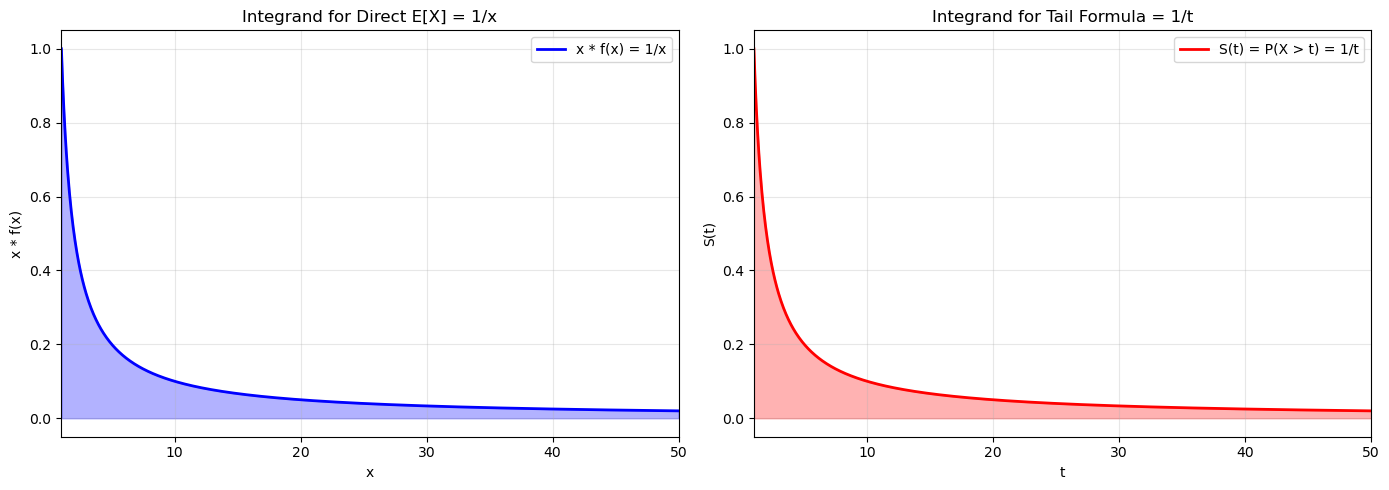

In [5]:
# --- Example 3: Infinite Expectation (Pareto alpha=1) ---
# f(x) = 1/x^2 for x >= 1. E[X] = infinity.

# Show divergence as upper limit increases
upper_limits = [10, 100, 1000, 10000]
results_direct = []
results_tail = []

for u in upper_limits:
    x_p = np.linspace(1, u, 20000)
    pdf_p = 1 / (x_p**2)
    E_dir = np.trapezoid(x_p * pdf_p, x_p)
    t_p = np.linspace(1, u, 20000)
    tail_p = 1 / t_p
    E_tail = np.trapezoid(tail_p, t_p)
    results_direct.append(E_dir)
    results_tail.append(E_tail)

print("Pareto(1,1) - Divergence of E[X]:")
print(f"{'Upper Limit':>12} {'Direct':>12} {'Tail':>12} {'log(L)':>12}")
print("-" * 55)
for u, d, ta in zip(upper_limits, results_direct, results_tail):
    print(f"{u:12d} {d:12.4f} {ta:12.4f} {np.log(u):12.4f}")

# Visualization of divergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PDF with shaded area growing
ax1 = axes[0]
x_plot = np.linspace(1, 50, 1000)
pdf_plot = 1 / (x_plot**2)
ax1.plot(x_plot, x_plot * pdf_plot, 'b-', linewidth=2, label='x * f(x) = 1/x')
ax1.fill_between(x_plot, x_plot * pdf_plot, alpha=0.3, color='blue')
ax1.set_xlabel('x')
ax1.set_ylabel('x * f(x)')
ax1.set_title('Integrand for Direct E[X] = 1/x')
ax1.set_xlim(1, 50)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: Tail survival function
ax2 = axes[1]
t_plot = np.linspace(1, 50, 1000)
ax2.plot(t_plot, 1/t_plot, 'r-', linewidth=2, label='S(t) = P(X > t) = 1/t')
ax2.fill_between(t_plot, 1/t_plot, alpha=0.3, color='red')
ax2.set_xlabel('t')
ax2.set_ylabel('S(t)')
ax2.set_title('Integrand for Tail Formula = 1/t')
ax2.set_xlim(1, 50)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## When Tonelli Fails: Loss of $\sigma$-Finiteness

Tonelli's theorem **requires** $\sigma$-finite measure spaces. Without this condition, the theorem can fail dramatically.

### Classic Counterexample
Let $X = [0,1]$ with **Lebesgue measure** $\lambda$ and $Y = [0,1]$ with **counting measure** $\nu$.

Counting measure on an uncountable set is **not** $\sigma$-finite, because any set of finite counting measure is finite, and $[0,1]$ is uncountable.

Define $f(x,y) = \mathbf{1}_{\{x = y\}}$.

### Computation
- For fixed $y \in Y$: $\int_X f(x,y) \, d\lambda(x) = \lambda(\{y\}) = 0$
  $$\Rightarrow \int_Y \int_X f \, d\lambda \, d\nu = \int_Y 0 \, d\nu = 0$$

- For fixed $x \in X$: $\int_Y f(x,y) \, d\nu(y) = \nu(\{x\}) = 1$
  $$\Rightarrow \int_X \int_Y f \, d\nu \, d\lambda = \int_X 1 \, d\lambda = 1$$

**Result**: $0 \neq 1$. The iterated integrals differ!

Since $f \geq 0$ is measurable, the failure is entirely due to the lack of $\sigma$-finiteness on $Y$.

### Key Insight
In probability, all standard spaces ($\mathbb{R}^n$, countable spaces) are $\sigma$-finite, so this pathology does not arise in typical applications. However, it is crucial for the theoretical foundations.


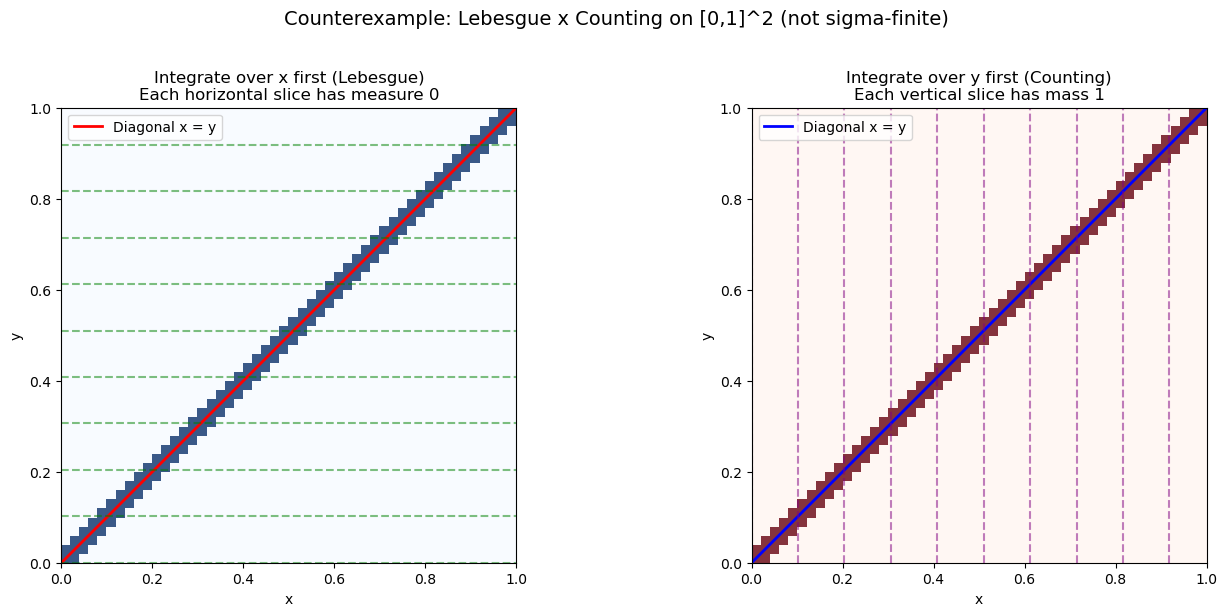

Note: This is a schematic illustration.
In the actual counterexample:
  int_X f(x,y) dlambda(x) = 0  for every y  =>  outer integral = 0
  int_Y f(x,y) dnu(y)     = 1  for every x  =>  outer integral = 1
  Tonelli fails because counting measure on [0,1] is NOT sigma-finite.


In [6]:
# --- Conceptual Visualization: The Counterexample ---
# We illustrate the diagonal measure counterexample schematically.

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Integrate over x first (Lebesgue) -> measure of diagonal slice is 0
ax1 = axes[0]
n_grid = 50
x_grid = np.linspace(0, 1, n_grid)
y_grid = np.linspace(0, 1, n_grid)
X_c, Y_c = np.meshgrid(x_grid, y_grid)

# Approximate diagonal
diagonal = np.abs(X_c - Y_c) < (1.5 / n_grid)
ax1.imshow(diagonal, extent=[0, 1, 0, 1], origin='lower', cmap='Blues', alpha=0.8)
ax1.plot(x_grid, x_grid, 'r-', linewidth=2, label='Diagonal x = y')
for i in range(0, n_grid, 5):
    ax1.axhline(y_grid[i], color='green', linestyle='--', alpha=0.5)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_title('Integrate over x first (Lebesgue)\nEach horizontal slice has measure 0')
ax1.legend()
ax1.set_aspect('equal')

# Right: Integrate over y first (Counting) -> each vertical slice has mass 1
ax2 = axes[1]
ax2.imshow(diagonal, extent=[0, 1, 0, 1], origin='lower', cmap='Reds', alpha=0.8)
ax2.plot(x_grid, x_grid, 'b-', linewidth=2, label='Diagonal x = y')
for i in range(0, n_grid, 5):
    ax2.axvline(x_grid[i], color='purple', linestyle='--', alpha=0.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Integrate over y first (Counting)\nEach vertical slice has mass 1')
ax2.legend()
ax2.set_aspect('equal')

plt.suptitle('Counterexample: Lebesgue x Counting on [0,1]^2 (not sigma-finite)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Note: This is a schematic illustration.")
print("In the actual counterexample:")
print("  int_X f(x,y) dlambda(x) = 0  for every y  =>  outer integral = 0")
print("  int_Y f(x,y) dnu(y)     = 1  for every x  =>  outer integral = 1")
print("  Tonelli fails because counting measure on [0,1] is NOT sigma-finite.")

## Summary

Tonelli's theorem provides the essential foundation for manipulating integrals over product spaces in probability and measure theory.

| Aspect | Tonelli's Theorem |
|--------|-------------------|
| **Function requirement** | $f \geq 0$ and measurable |
| **Measure requirement** | Both spaces $\sigma$-finite |
| **Result** | Iterated integrals equal product integral (value in $[0, \infty]$) |
| **Probabilistic use** | Tail formulas, non-negative expectations, checking $|f|$ for Fubini |
| **Failure mode** | Without $\sigma$-finiteness, iterated integrals may differ |

### Key Probability Applications
1. **Tail expectation**: $\mathbb{E}[X] = \int_0^\infty \mathbb{P}(X > t) \, dt$ for $X \geq 0$
2. **Joint expectations**: $\mathbb{E}[g(X,Y)]$ computed as iterated integral for any $g \geq 0$
3. **Fubini check**: Apply Tonelli to $|f|$ to verify absolute integrability before applying Fubini to $f$

In [7]:
# --- Self-Contained Final Verification ---
import numpy as np

print("=" * 65)
print("TONELLI'S THEOREM VERIFICATION SUMMARY")
print("=" * 65)

# 1. Tail probability (finite case)
lam = 0.5
t = np.linspace(0, 100, 20000)
survival = np.exp(-lam * t)
E_tail = np.trapezoid(survival, t)
x = np.linspace(0, 100, 20000)
pdf = lam * np.exp(-lam * x)
E_direct = np.trapezoid(x * pdf, x)

print("\n1. Tail Probability Formula (Exponential, finite)")
print(f"   E[X] via tail:   {E_tail:.6f}")
print(f"   E[X] direct:     {E_direct:.6f}")
print(f"   Analytical:      {1/lam:.6f}")
print(f"   Tonelli valid:   {np.isclose(E_tail, E_direct)}")

# 2. Joint expectation (non-negative, finite)
lim = 15
n = 400
x_j = np.linspace(0, lim, n)
y_j = np.linspace(0, lim, n)
X_j, Y_j = np.meshgrid(x_j, y_j)
joint = np.exp(-(X_j + Y_j))
g = X_j * Y_j * joint
inner_y = np.array([np.trapezoid(g[i, :], y_j) for i in range(len(x_j))])
E_xy_1 = np.trapezoid(inner_y, x_j)
inner_x = np.array([np.trapezoid(g[:, j], x_j) for j in range(len(y_j))])
E_xy_2 = np.trapezoid(inner_x, y_j)

print("\n2. Joint Expectation E[XY] (Exp(1) x Exp(1))")
print(f"   Order dy dx:     {E_xy_1:.6f}")
print(f"   Order dx dy:     {E_xy_2:.6f}")
print(f"   Analytical:      1.000000")
print(f"   Tonelli valid:   {np.isclose(E_xy_1, E_xy_2)}")

# 3. Infinite expectation (Pareto)
u = 10000
x_p = np.linspace(1, u, 20000)
E_inf_dir = np.trapezoid(x_p * (1/x_p**2), x_p)
t_p = np.linspace(1, u, 20000)
E_inf_tail = np.trapezoid(1/t_p, t_p)

print("\n3. Infinite Expectation (Pareto alpha=1)")
print(f"   Direct integral to {u}:  {E_inf_dir:.4f}")
print(f"   Tail integral to {u}:    {E_inf_tail:.4f}")
print(f"   Both diverge as limit -> infinity (logarithmic growth)")
print(f"   Tonelli correctly yields +infinity")

print("\n" + "=" * 65)
print("All verifications complete.")
print("=" * 65)


TONELLI'S THEOREM VERIFICATION SUMMARY

1. Tail Probability Formula (Exponential, finite)
   E[X] via tail:   2.000001
   E[X] direct:     1.999999
   Analytical:      2.000000
   Tonelli valid:   True

2. Joint Expectation E[XY] (Exp(1) x Exp(1))
   Order dy dx:     0.999755
   Order dx dy:     0.999755
   Analytical:      1.000000
   Tonelli valid:   True

3. Infinite Expectation (Pareto alpha=1)
   Direct integral to 10000:  9.2307
   Tail integral to 10000:    9.2307
   Both diverge as limit -> infinity (logarithmic growth)
   Tonelli correctly yields +infinity

All verifications complete.
